<a href="https://colab.research.google.com/github/NavdeeepSinghh/Deep_Learning-LAB/blob/main/DL_Lab_Work__NEU_DATASET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 NEU Surface Defect Database — 6-Model Comparison
**Models:** ResNet-34 | ResNet-50 | InceptionNet | EfficientNet-B0 | AlexNet | VGG16  
**Task:** Multi-class surface defect classification (6 classes)  
**Plot:** Accuracy vs Loss curves for all models

In [3]:
from google.colab import files
uploaded = files.upload()

Saving NEU-DET-2.zip to NEU-DET-2.zip


In [4]:
!unzip NEU-DET-2.zip

Streaming output truncated to the last 5000 lines.
  inflating: NEU-DET-2/train/annotations/pitted_surface_31.xml  
  inflating: __MACOSX/NEU-DET-2/train/annotations/._pitted_surface_31.xml  
  inflating: NEU-DET-2/train/annotations/patches_154.xml  
  inflating: __MACOSX/NEU-DET-2/train/annotations/._patches_154.xml  
  inflating: NEU-DET-2/train/annotations/pitted_surface_25.xml  
  inflating: __MACOSX/NEU-DET-2/train/annotations/._pitted_surface_25.xml  
  inflating: NEU-DET-2/train/annotations/patches_140.xml  
  inflating: __MACOSX/NEU-DET-2/train/annotations/._patches_140.xml  
  inflating: NEU-DET-2/train/annotations/crazing_80.xml  
  inflating: __MACOSX/NEU-DET-2/train/annotations/._crazing_80.xml  
  inflating: NEU-DET-2/train/annotations/patches_168.xml  
  inflating: __MACOSX/NEU-DET-2/train/annotations/._patches_168.xml  
  inflating: NEU-DET-2/train/annotations/scratches_213.xml  
  inflating: __MACOSX/NEU-DET-2/train/annotations/._scratches_213.xml  
  inflating: NEU-DET

In [5]:
import os
import glob

# Auto-detect the image root directory (folder containing class subfolders)
def find_dataset_root(base='/content/NEU-DET-2'):
    for root, dirs, files in os.walk(base):
        # If this folder has subfolders containing images → it's the class root
        img_subdirs = [d for d in dirs if len(glob.glob(os.path.join(root, d, '*.jpg')) +
                                                glob.glob(os.path.join(root, d, '*.png')) +
                                                glob.glob(os.path.join(root, d, '*.bmp'))) > 0]
        if len(img_subdirs) >= 4:  # NEU has 6 classes
            return root
    return base

DATA_ROOT = find_dataset_root()
print(f"📂 Dataset root detected: {DATA_ROOT}")
print(f"🏷️  Classes found: {sorted(os.listdir(DATA_ROOT))}")

📂 Dataset root detected: /content/NEU-DET-2/validation/images
🏷️  Classes found: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────
#  GLOBAL CONFIG  (tweak here)
# ──────────────────────────────────────────────
IMG_SIZE    = 224          # All models expect 224×224 (InceptionV3 needs 299 but we resize)
BATCH_SIZE  = 32
EPOCHS      = 15           # Increase for better accuracy; 15 is good for comparison
LR          = 1e-4
DROPOUT_P   = 0.5          # Single dropout rate applied to all models
VAL_SPLIT   = 0.2
SEED        = 42
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"🖥️  Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

torch.manual_seed(SEED)
np.random.seed(SEED)

🖥️  Device: cuda
   GPU: Tesla T4


## 🔄 Step 5: Data Transforms & DataLoaders


In [7]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(DATA_ROOT)
NUM_CLASSES  = len(full_dataset.classes)
print(f"📊 Total images : {len(full_dataset)}")
print(f"🏷️  Classes ({NUM_CLASSES}): {full_dataset.classes}")

val_size   = int(VAL_SPLIT * len(full_dataset))
train_size = len(full_dataset) - val_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size],
                                 generator=torch.Generator().manual_seed(SEED))

# Apply transforms individually
train_ds.dataset = deepcopy(full_dataset)
train_ds.dataset.transform = train_transforms
val_dataset = datasets.ImageFolder(DATA_ROOT, transform=val_transforms)
val_ds_final = torch.utils.data.Subset(val_dataset, val_ds.indices)

train_loader = DataLoader(train_ds,      batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds_final,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"\n✅ Train: {len(train_ds)} | Val: {len(val_ds_final)}")

📊 Total images : 360
🏷️  Classes (6): ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

✅ Train: 288 | Val: 72


In [8]:
def get_model(name, num_classes, dropout_p):
    """
    Returns a pretrained model with the classifier head replaced.
    A single Dropout(dropout_p) layer is inserted before the final FC.
    """
    name = name.lower()

    # ── ResNet-34 ──────────────────────────────────────────────────────────
    if name == 'resnet34':
        model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        in_feats = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(in_feats, num_classes)
        )

    # ── ResNet-50 ──────────────────────────────────────────────────────────
    elif name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        in_feats = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(in_feats, num_classes)
        )

    # ── InceptionV3 ────────────────────────────────────────────────────────
    elif name == 'inceptionnet':
        model = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
        model.aux_logits = False          # disable aux head for simplicity
        in_feats = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(in_feats, num_classes)
        )

    # ── EfficientNet-B0 ────────────────────────────────────────────────────
    elif name == 'efficientnet':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        in_feats = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(in_feats, num_classes)
        )

    # ── AlexNet ────────────────────────────────────────────────────────────
    elif name == 'alexnet':
        model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
        in_feats = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_feats, num_classes)
        # Insert dropout before the new final layer (position 5→6)
        model.classifier[5] = nn.Dropout(p=dropout_p)

    # ── VGG-16 ─────────────────────────────────────────────────────────────
    elif name == 'vgg16':
        model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        in_feats = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_feats, num_classes)
        model.classifier[5] = nn.Dropout(p=dropout_p)

    else:
        raise ValueError(f"Unknown model: {name}")

    return model


# Registry — (display_name, key, color)
MODEL_REGISTRY = [
    ('ResNet-34',    'resnet34',     '#E63946'),
    ('ResNet-50',    'resnet50',     '#F4A261'),
    ('InceptionNet', 'inceptionnet', '#2A9D8F'),
    ('EfficientNet', 'efficientnet', '#457B9D'),
    ('AlexNet',      'alexnet',      '#9B5DE5'),
    ('VGG16',        'vgg16',        '#F15BB5'),
]

print("✅ Model definitions ready.")
print(f"   Dropout probability: {DROPOUT_P}")

✅ Model definitions ready.
   Dropout probability: 0.5


## 🏋️ Step 7: Training & Validation Loop


In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total


def train_model(display_name, key, device, epochs=EPOCHS):
    print(f"\n{'='*55}")
    print(f"  Training: {display_name}")
    print(f"{'='*55}")

    # InceptionV3 needs 299×299 input — rebuild loaders if needed
    if key == 'inceptionnet':
        inc_train_tf = transforms.Compose([
            transforms.Resize((299, 299)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
        inc_val_tf = transforms.Compose([
            transforms.Resize((299, 299)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
        t_ds = datasets.ImageFolder(DATA_ROOT, transform=inc_train_tf)
        v_ds = datasets.ImageFolder(DATA_ROOT, transform=inc_val_tf)
        t_sub = torch.utils.data.Subset(t_ds, train_ds.indices)
        v_sub = torch.utils.data.Subset(v_ds, val_ds.indices)
        t_loader = DataLoader(t_sub, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
        v_loader = DataLoader(v_sub, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    else:
        t_loader, v_loader = train_loader, val_loader

    model     = get_model(key, NUM_CLASSES, DROPOUT_P).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, t_loader, criterion, optimizer, device)
        vl_loss, vl_acc = evaluate(model, v_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc * 100)
        history['val_acc'].append(vl_acc * 100)

        print(f"  Epoch [{epoch:02d}/{epochs}]  "
              f"Train Loss: {tr_loss:.4f} | Acc: {tr_acc*100:.2f}%   "
              f"Val Loss: {vl_loss:.4f} | Acc: {vl_acc*100:.2f}%")

    print(f"  ✅ Final Val Acc: {history['val_acc'][-1]:.2f}%")
    del model
    torch.cuda.empty_cache()
    return history

## 🚀 Step 8: Run All 6 Models


In [10]:
#%% md
## 🚀 Step 8: Run All 6 Models
#%%
all_histories = {}   # { display_name: history_dict }

for display_name, key, color in MODEL_REGISTRY:
    hist = train_model(display_name, key, DEVICE, epochs=EPOCHS)
    all_histories[display_name] = {'history': hist, 'color': color}

print("\n" + "="*55)
print("  ✅ All 6 models trained!")
print("="*55)
print(f"\n{'Model':<15} {'Best Val Acc':>14}")
print("-"*30)
for name, data in all_histories.items():
    best = max(data['history']['val_acc'])
    print(f"{name:<15} {best:>13.2f}%")


  Training: ResNet-34
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 191MB/s]


  Epoch [01/15]  Train Loss: 1.3118 | Acc: 52.43%   Val Loss: 0.7962 | Acc: 70.83%
  Epoch [02/15]  Train Loss: 0.2501 | Acc: 93.75%   Val Loss: 0.2716 | Acc: 90.28%
  Epoch [03/15]  Train Loss: 0.0657 | Acc: 98.61%   Val Loss: 0.1467 | Acc: 91.67%
  Epoch [04/15]  Train Loss: 0.0381 | Acc: 100.00%   Val Loss: 0.0170 | Acc: 100.00%
  Epoch [05/15]  Train Loss: 0.0299 | Acc: 99.31%   Val Loss: 0.0049 | Acc: 100.00%
  Epoch [06/15]  Train Loss: 0.0186 | Acc: 99.65%   Val Loss: 0.0036 | Acc: 100.00%
  Epoch [07/15]  Train Loss: 0.0126 | Acc: 100.00%   Val Loss: 0.0019 | Acc: 100.00%
  Epoch [08/15]  Train Loss: 0.0163 | Acc: 100.00%   Val Loss: 0.0013 | Acc: 100.00%
  Epoch [09/15]  Train Loss: 0.0082 | Acc: 100.00%   Val Loss: 0.0013 | Acc: 100.00%
  Epoch [10/15]  Train Loss: 0.0094 | Acc: 100.00%   Val Loss: 0.0012 | Acc: 100.00%
  Epoch [11/15]  Train Loss: 0.0167 | Acc: 99.65%   Val Loss: 0.0011 | Acc: 100.00%
  Epoch [12/15]  Train Loss: 0.0107 | Acc: 100.00%   Val Loss: 0.0012 | Ac

100%|██████████| 97.8M/97.8M [00:00<00:00, 177MB/s]


  Epoch [01/15]  Train Loss: 1.6815 | Acc: 34.03%   Val Loss: 1.6590 | Acc: 48.61%
  Epoch [02/15]  Train Loss: 1.2913 | Acc: 80.21%   Val Loss: 1.4124 | Acc: 80.56%
  Epoch [03/15]  Train Loss: 0.9201 | Acc: 92.01%   Val Loss: 1.0936 | Acc: 95.83%
  Epoch [04/15]  Train Loss: 0.5551 | Acc: 94.44%   Val Loss: 0.7477 | Acc: 94.44%
  Epoch [05/15]  Train Loss: 0.2746 | Acc: 98.96%   Val Loss: 0.4214 | Acc: 95.83%
  Epoch [06/15]  Train Loss: 0.1276 | Acc: 98.96%   Val Loss: 0.2168 | Acc: 98.61%
  Epoch [07/15]  Train Loss: 0.0734 | Acc: 99.65%   Val Loss: 0.0988 | Acc: 100.00%
  Epoch [08/15]  Train Loss: 0.0700 | Acc: 98.96%   Val Loss: 0.0355 | Acc: 100.00%
  Epoch [09/15]  Train Loss: 0.0690 | Acc: 98.61%   Val Loss: 0.0137 | Acc: 100.00%
  Epoch [10/15]  Train Loss: 0.0530 | Acc: 99.31%   Val Loss: 0.0110 | Acc: 100.00%
  Epoch [11/15]  Train Loss: 0.0429 | Acc: 99.31%   Val Loss: 0.0095 | Acc: 100.00%
  Epoch [12/15]  Train Loss: 0.0338 | Acc: 99.65%   Val Loss: 0.0075 | Acc: 100.00

...

  Epoch [01/15]  Train Loss: 1.5976 | Acc: 42.01%   Val Loss: 1.6513 | Acc: 43.06%
  Epoch [02/15]  Train Loss: 1.2022 | Acc: 83.68%   Val Loss: 1.1986 | Acc: 80.56%
  Epoch [03/15]  Train Loss: 0.8513 | Acc: 94.44%   Val Loss: 0.8672 | Acc: 90.28%
  Epoch [04/15]  Train Loss: 0.6003 | Acc: 97.22%   Val Loss: 0.5650 | Acc: 100.00%
  Epoch [05/15]  Train Loss: 0.4142 | Acc: 97.22%   Val Loss: 0.3400 | Acc: 100.00%
  Epoch [06/15]  Train Loss: 0.2806 | Acc: 98.26%   Val Loss: 0.1833 | Acc: 100.00%
  Epoch [07/15]  Train Loss: 0.2597 | Acc: 96.88%   Val Loss: 0.1053 | Acc: 100.00%
  Epoch [08/15]  Train Loss: 0.1764 | Acc: 99.31%   Val Loss: 0.0701 | Acc: 100.00%
  Epoch [09/15]  Train Loss: 0.1235 | Acc: 99.65%   Val Loss: 0.0615 | Acc: 100.00%
  Epoch [10/15]  Train Loss: 0.1331 | Acc: 98.61%   Val Loss: 0.0543 | Acc: 100.00%
  Epoch [11/15]  Train Loss: 0.1093 | Acc: 98.96%   Val Loss: 0.0543 | Acc: 100.00%
  Epoch [12/15]  Train Loss: 0.0954 | Acc: 99.31%   Val Loss: 0.0497 | Acc: 100

100%|██████████| 233M/233M [00:01<00:00, 182MB/s]


  Epoch [01/15]  Train Loss: 1.7197 | Acc: 50.35%   Val Loss: 0.5118 | Acc: 79.17%
  Epoch [02/15]  Train Loss: 0.3779 | Acc: 86.11%   Val Loss: 0.0627 | Acc: 97.22%
  Epoch [03/15]  Train Loss: 0.0929 | Acc: 96.53%   Val Loss: 0.0369 | Acc: 97.22%
  Epoch [04/15]  Train Loss: 0.0614 | Acc: 97.22%   Val Loss: 0.0783 | Acc: 98.61%
  Epoch [05/15]  Train Loss: 0.0758 | Acc: 98.26%   Val Loss: 0.0013 | Acc: 100.00%
  Epoch [06/15]  Train Loss: 0.0573 | Acc: 98.26%   Val Loss: 0.0074 | Acc: 100.00%
  Epoch [07/15]  Train Loss: 0.0647 | Acc: 97.57%   Val Loss: 0.0290 | Acc: 98.61%
  Epoch [08/15]  Train Loss: 0.0374 | Acc: 98.61%   Val Loss: 0.0028 | Acc: 100.00%
  Epoch [09/15]  Train Loss: 0.0346 | Acc: 98.61%   Val Loss: 0.0006 | Acc: 100.00%
  Epoch [10/15]  Train Loss: 0.0109 | Acc: 99.65%   Val Loss: 0.0005 | Acc: 100.00%
  Epoch [11/15]  Train Loss: 0.0114 | Acc: 99.65%   Val Loss: 0.0005 | Acc: 100.00%
  Epoch [12/15]  Train Loss: 0.0025 | Acc: 100.00%   Val Loss: 0.0003 | Acc: 100.

100%|██████████| 528M/528M [00:07<00:00, 74.4MB/s]


  Epoch [01/15]  Train Loss: 1.1601 | Acc: 60.42%   Val Loss: 0.1983 | Acc: 97.22%
  Epoch [02/15]  Train Loss: 0.2058 | Acc: 93.75%   Val Loss: 0.0069 | Acc: 100.00%
  Epoch [03/15]  Train Loss: 0.0880 | Acc: 97.22%   Val Loss: 0.0395 | Acc: 98.61%
  Epoch [04/15]  Train Loss: 0.0620 | Acc: 97.22%   Val Loss: 0.0007 | Acc: 100.00%
  Epoch [05/15]  Train Loss: 0.0377 | Acc: 98.96%   Val Loss: 0.0005 | Acc: 100.00%
  Epoch [06/15]  Train Loss: 0.0098 | Acc: 99.31%   Val Loss: 0.0016 | Acc: 100.00%
  Epoch [07/15]  Train Loss: 0.0198 | Acc: 99.31%   Val Loss: 0.0005 | Acc: 100.00%
  Epoch [08/15]  Train Loss: 0.0024 | Acc: 100.00%   Val Loss: 0.0001 | Acc: 100.00%
  Epoch [09/15]  Train Loss: 0.0001 | Acc: 100.00%   Val Loss: 0.0001 | Acc: 100.00%
  Epoch [10/15]  Train Loss: 0.0182 | Acc: 99.65%   Val Loss: 0.0001 | Acc: 100.00%
  Epoch [11/15]  Train Loss: 0.0012 | Acc: 100.00%   Val Loss: 0.0002 | Acc: 100.00%
  Epoch [12/15]  Train Loss: 0.0075 | Acc: 99.65%   Val Loss: 0.0001 | Acc:

## 📊 Step 9: Plot — Accuracy & Loss Curves (All Models)


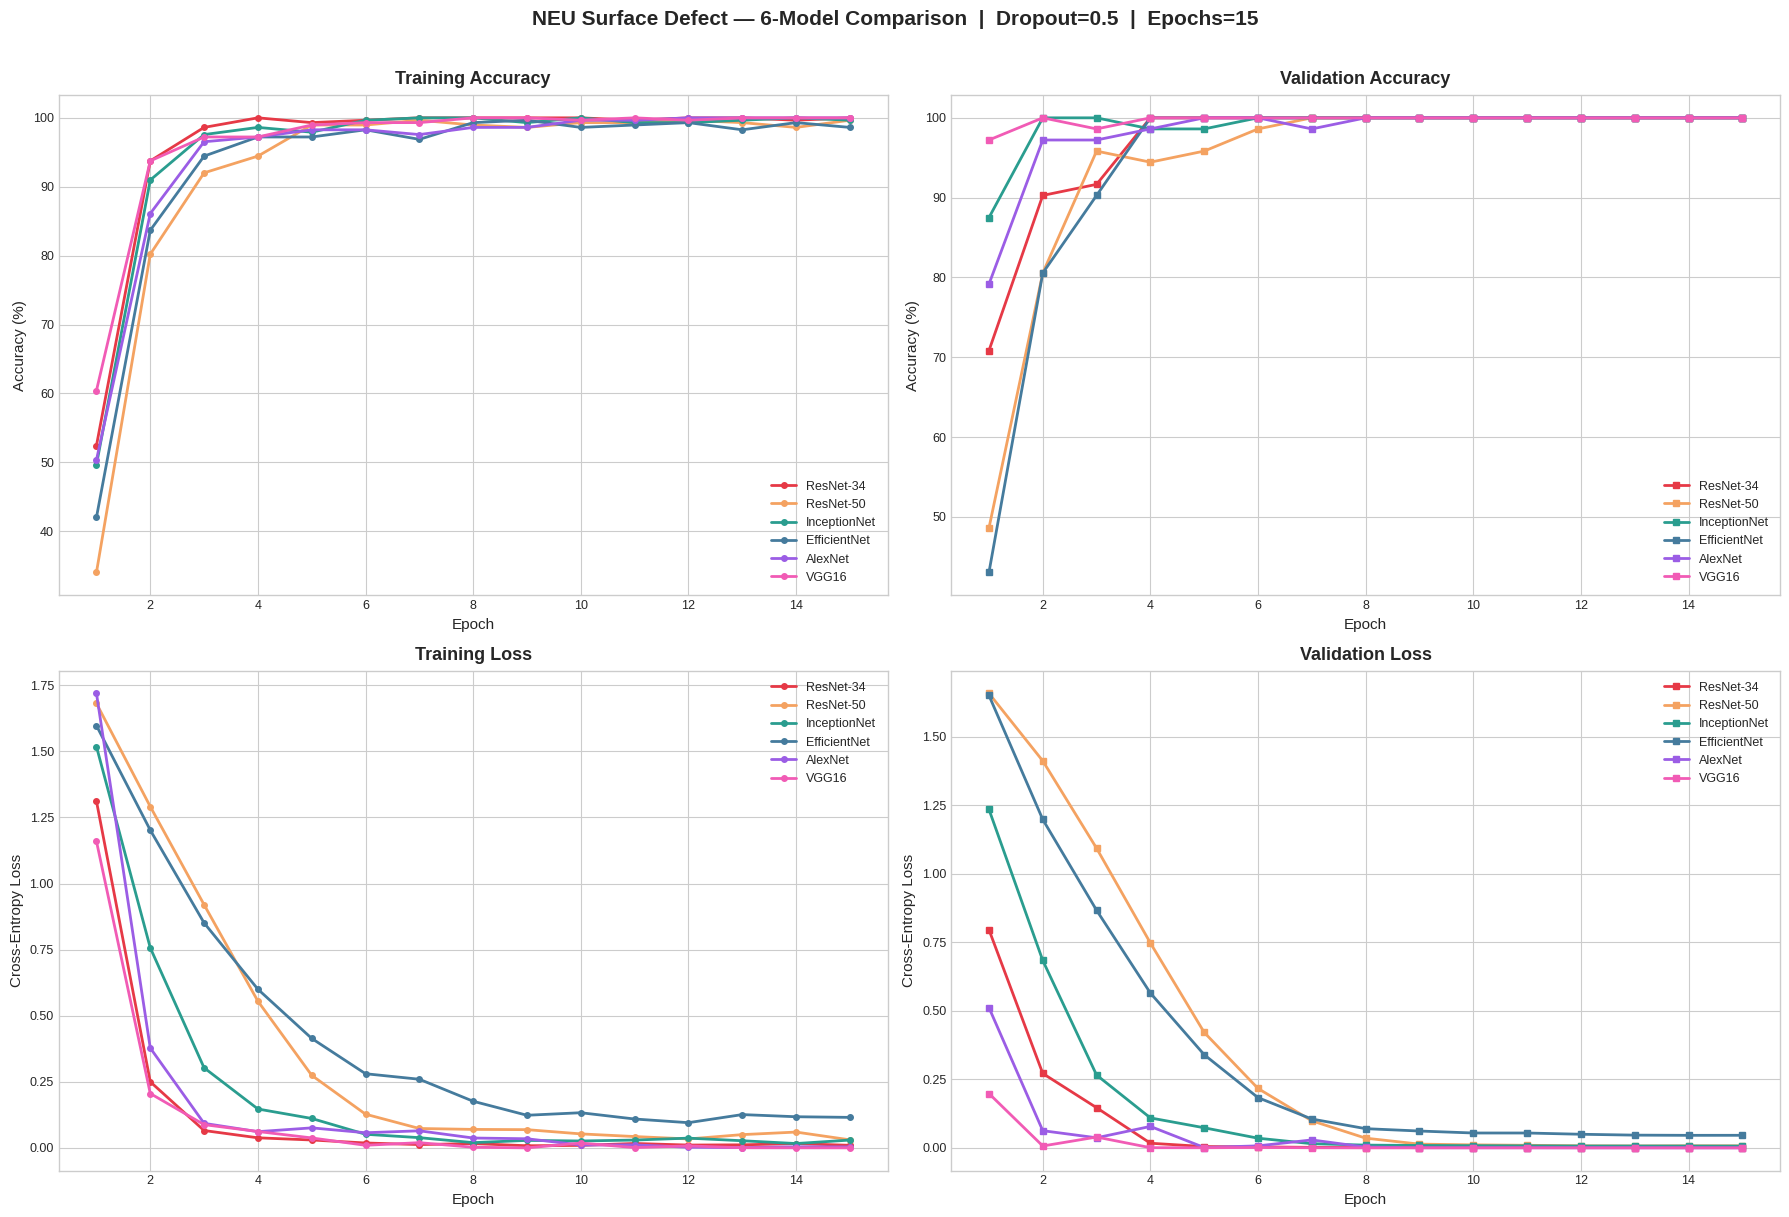

📁 Saved: neu_6models_acc_loss.png


In [11]:
# ── Plot settings ───────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
epochs_x = range(1, EPOCHS + 1)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(
    f'NEU Surface Defect — 6-Model Comparison  |  Dropout={DROPOUT_P}  |  Epochs={EPOCHS}',
    fontsize=15, fontweight='bold', y=1.01
)

ax_tacc, ax_vacc = axes[0]
ax_tloss, ax_vloss = axes[1]

for name, data in all_histories.items():
    h   = data['history']
    c   = data['color']
    lw  = 2.0

    ax_tacc.plot(epochs_x,  h['train_acc'],  color=c, lw=lw, marker='o', ms=4, label=name)
    ax_vacc.plot(epochs_x,  h['val_acc'],    color=c, lw=lw, marker='s', ms=4, label=name)
    ax_tloss.plot(epochs_x, h['train_loss'], color=c, lw=lw, marker='o', ms=4, label=name)
    ax_vloss.plot(epochs_x, h['val_loss'],   color=c, lw=lw, marker='s', ms=4, label=name)

def _style(ax, title, ylabel, xlabel='Epoch'):
    ax.set_title(title, fontsize=13, fontweight='bold', pad=8)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=9, loc='best', framealpha=0.8)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.tick_params(labelsize=9)

_style(ax_tacc,  'Training Accuracy',   'Accuracy (%)')
_style(ax_vacc,  'Validation Accuracy', 'Accuracy (%)')
_style(ax_tloss, 'Training Loss',       'Cross-Entropy Loss')
_style(ax_vloss, 'Validation Loss',     'Cross-Entropy Loss')

plt.tight_layout()
plt.savefig('neu_6models_acc_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved: neu_6models_acc_loss.png")

## 📊 Step 10: Bonus — Combined Overlay Comparison


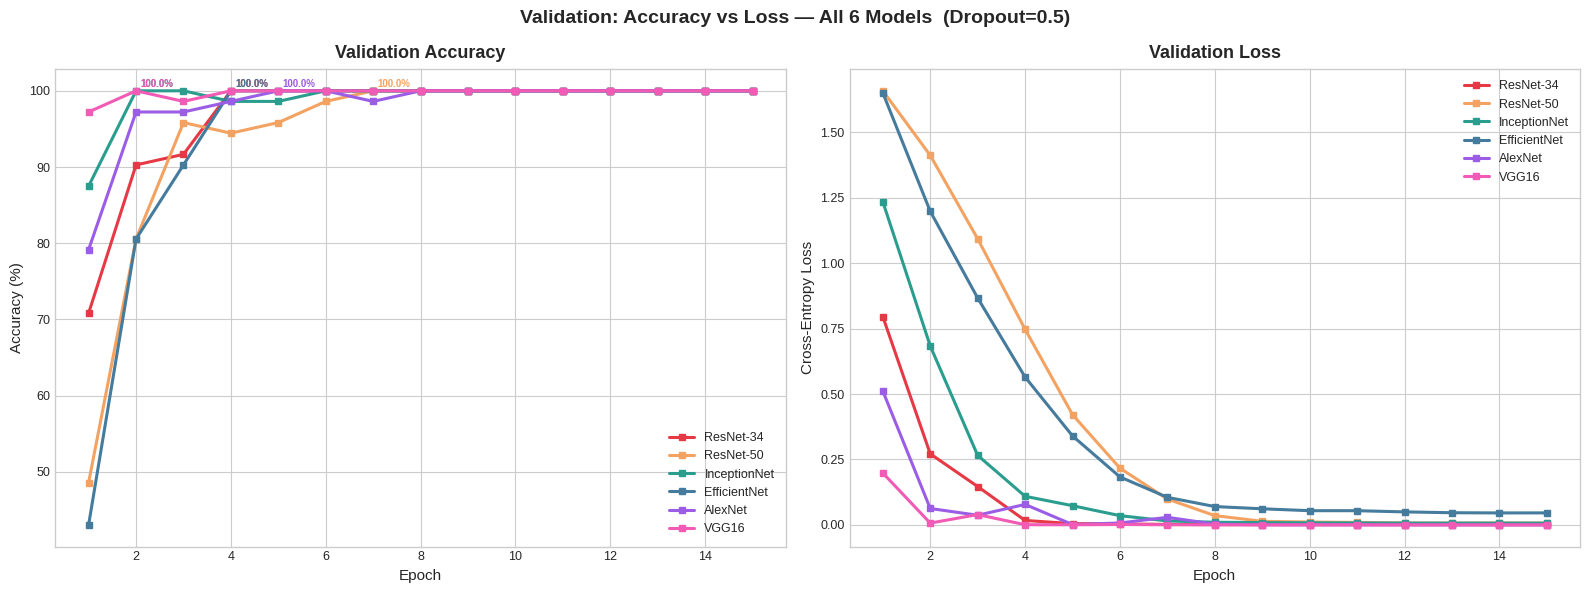

📁 Saved: neu_6models_val_overlay.png


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'Validation: Accuracy vs Loss — All 6 Models  (Dropout={DROPOUT_P})',
    fontsize=14, fontweight='bold'
)

for name, data in all_histories.items():
    h, c = data['history'], data['color']
    ax1.plot(epochs_x, h['val_acc'],  color=c, lw=2.2, marker='s', ms=5, label=name)
    ax2.plot(epochs_x, h['val_loss'], color=c, lw=2.2, marker='s', ms=5, label=name)

_style(ax1, 'Validation Accuracy',   'Accuracy (%)')
_style(ax2, 'Validation Loss',       'Cross-Entropy Loss')

# Annotate best val acc
for name, data in all_histories.items():
    h, c = data['history'], data['color']
    best_ep  = np.argmax(h['val_acc']) + 1
    best_val = max(h['val_acc'])
    ax1.annotate(f"{best_val:.1f}%",
                 xy=(best_ep, best_val),
                 xytext=(3, 3), textcoords='offset points',
                 fontsize=7, color=c, fontweight='bold')

plt.tight_layout()
plt.savefig('neu_6models_val_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved: neu_6models_val_overlay.png")

## 📋 Step 11: Summary Table


In [13]:
print(f"\n{'='*62}")
print(f"  FINAL SUMMARY — NEU Surface Defect (Dropout={DROPOUT_P}, Epochs={EPOCHS})")
print(f"{'='*62}")
print(f"{'Model':<15} {'Best Val Acc':>13} {'Final Val Acc':>14} {'Final Val Loss':>15}")
print("-"*62)

results = []
for name, data in all_histories.items():
    h = data['history']
    best_acc  = max(h['val_acc'])
    final_acc = h['val_acc'][-1]
    final_loss= h['val_loss'][-1]
    results.append((name, best_acc, final_acc, final_loss))

results.sort(key=lambda x: x[1], reverse=True)
for name, best, final_a, final_l in results:
    print(f"{name:<15} {best:>12.2f}% {final_a:>13.2f}% {final_l:>15.4f}")

print(f"{'='*62}")
print(f"\n🏆 Best model: {results[0][0]} ({results[0][1]:.2f}% best val accuracy)")


  FINAL SUMMARY — NEU Surface Defect (Dropout=0.5, Epochs=15)
Model            Best Val Acc  Final Val Acc  Final Val Loss
--------------------------------------------------------------
ResNet-34             100.00%        100.00%          0.0012
ResNet-50             100.00%        100.00%          0.0074
InceptionNet          100.00%        100.00%          0.0065
EfficientNet          100.00%        100.00%          0.0459
AlexNet               100.00%        100.00%          0.0002
VGG16                 100.00%        100.00%          0.0001

🏆 Best model: ResNet-34 (100.00% best val accuracy)


In [14]:
#%% md
## 💾 Step 12: Download Plots
#%%
from google.colab import files
files.download('neu_6models_acc_loss.png')
files.download('neu_6models_val_overlay.png')
print("✅ Both plots downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Both plots downloaded!
